In [1]:
import pandas as pd
csv_path = r"..\..\data\massa_RS_v1.csv"
# ../../data/RS_v1
# --- Replace with your actual data file ---
df = pd.read_csv(csv_path)

# --- Replace with the name of your datetime column ---
time_col = "date"

# Try parsing timestamps safely
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# Drop unparseable (NaT) timestamps
n_invalid = df[time_col].isna().sum()
print(f"❗ Invalid timestamps dropped: {n_invalid}")

df = df.dropna(subset=[time_col]).sort_values(time_col)

# Set index for convenience
df = df.set_index(time_col)

# --- Check continuity ---
# Compute time difference between consecutive timestamps
diffs = df.index.to_series().diff()

# Count missing hours
expected_delta = pd.Timedelta(hours=1)
missing = (diffs > expected_delta).sum()
duplicates = (diffs == pd.Timedelta(0)).sum()

print(f"✅ Total records: {len(df)}")
print(f"🕓 Missing hourly steps: {missing}")
print(f"🔁 Duplicate timestamps: {duplicates}")

# --- Optionally print missing timestamp ranges ---
if missing > 0:
    gap_starts = df.index[diffs > expected_delta]
    print("\n⚠️ Missing timestamp starts (showing first few):")
    print(gap_starts[:10])


❗ Invalid timestamps dropped: 0
✅ Total records: 32945
🕓 Missing hourly steps: 0
🔁 Duplicate timestamps: 0


Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32945 entries, 0 to 32944
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   date                                 32945 non-null  object 
 1   streamflow                           32945 non-null  float64
 2   streamflow_hindcast                  32945 non-null  float64
 3   Massa|22_Q simule                    32945 non-null  float64
 4   Massa|69_i                           32945 non-null  float64
 5   Massa|69_T                           32945 non-null  float64
 6   Massa|70_h                           32945 non-null  float64
 7   Massa|71_h                           32945 non-null  float64
 8   Massa|71_A                           32945 non-null  int64  
 9   Massa|73_H                           32945 non-null  float64
 10  Massa|73_A                           32945 non-null  int64  
 11  DayOfYearSinu

,count,mean,std,min,25%,50%,75%,max
Massa|22_Q simule,32945.0,17.581500,22.263011,0.196281,0.442785,4.696972,32.154984,106.620674
fc_Massa|22_Q simule,18002.0,32.662316,23.286843,0.159933,11.861757,30.084132,49.606172,109.953230


,mean,std,median,min,max,skew,kurtosis,zeros,negatives
Massa|22_Q simule,17.581500,22.263011,4.696972,0.196281,106.620674,1.203787,0.417355,0,0
fc_Massa|22_Q simule,32.662316,23.286843,30.084132,0.159933,109.953230,0.493522,-0.676924,0,0



Pearson correlation: 0.97183

Difference Summary:


,diff,rel_diff_%
count,18002.000000,18002.000000
mean,-1.234194,5.757809
std,5.527344,45.940792
min,-53.586150,-67.790982
25%,-4.326065,-14.453198
50%,-1.015705,-4.180035
75%,2.071564,10.774750
max,23.258620,462.450749


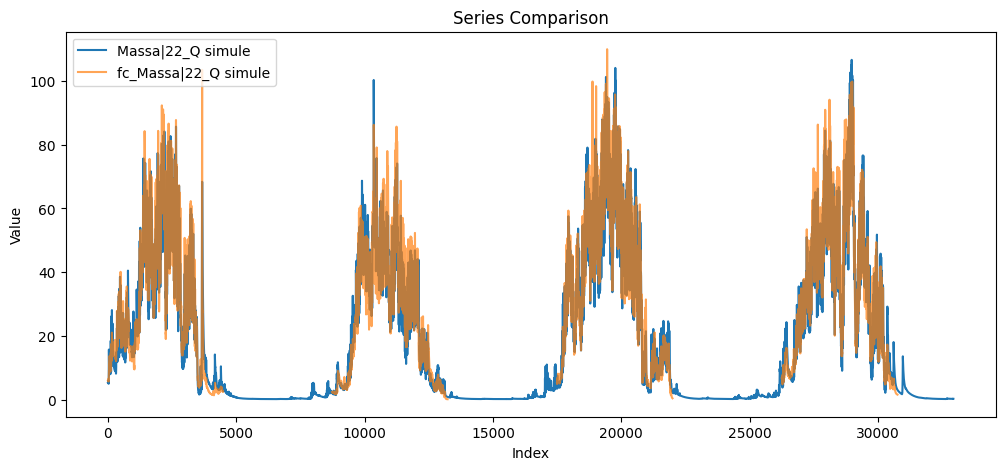

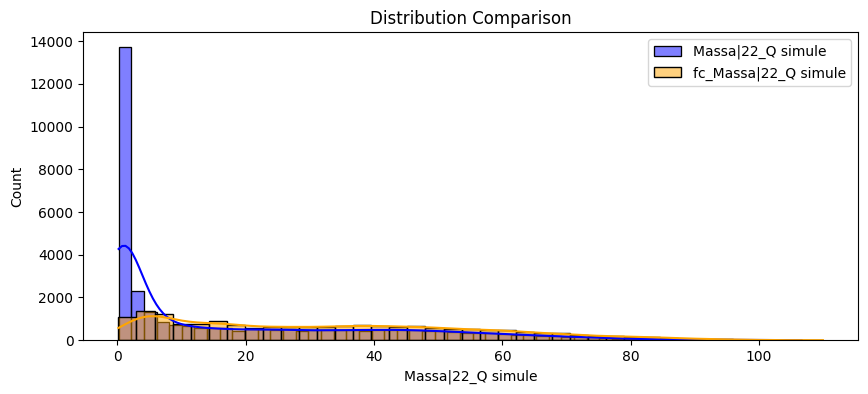

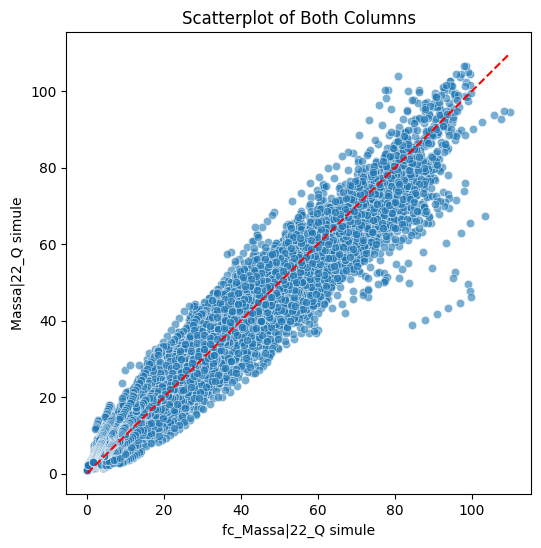


MAPE for streamflow: 5.0000%
MAPE for streamflow_josep: nan%

Rows with >100% relative difference:


,date,streamflow,streamflow_hindcast,Massa|22_Q simule,Massa|69_i,Massa|69_T,Massa|70_h,Massa|71_h,Massa|71_A,Massa|73_H,...,fc_Massa|71_A,fc_Massa|72_h,fc_Massa|73_Q,fc_Massa|73_QNeige,fc_Massa|73_QGlace,fc_Massa|73_H,fc_Massa|73_A,diff,rel_diff_%,abs_pct_error
3761,2020-10-07 01:00,9.346666,9.346666,14.156345,3.050000e-07,-3.272909,0.140801,0.042475,83138136,60.195797,...,83138136.0,0.006276,3.222865,0.005011,0.124072,63.502155,115295630.0,7.147442,101.976600,101.976600
3762,2020-10-07 02:00,9.059999,9.059999,14.023484,9.400000e-08,-3.169572,0.141114,0.042343,83138136,60.195827,...,83138136.0,0.006243,3.155731,0.004360,0.116007,63.502174,115295630.0,7.085717,102.132542,102.132542
3763,2020-10-07 03:00,8.926666,8.926666,13.813334,2.870000e-08,-3.296641,0.141188,0.042203,83138136,60.195847,...,83138136.0,0.006204,3.059505,0.003793,0.108467,63.502197,115295630.0,6.982868,102.231223,102.231223
3764,2020-10-07 04:00,8.768333,8.768333,13.613592,5.490000e-08,-3.311765,0.141348,0.042065,83138136,60.195870,...,83138136.0,0.006164,2.966395,0.003300,0.101417,63.502213,115295630.0,6.891247,102.512534,102.512534
3765,2020-10-07 05:00,8.671666,8.671666,13.423549,2.140000e-07,-3.261381,0.142047,0.041954,83138136,60.195885,...,83138136.0,0.006126,2.875310,0.002871,0.094825,63.502230,115295630.0,6.807622,102.897478,102.897478
3766,2020-10-07 06:00,8.500000,8.500000,13.256187,1.460000e-07,-3.559931,0.142529,0.041823,83138136,60.195910,...,83138136.0,0.006087,2.786908,0.002498,0.088661,63.502262,115295630.0,6.743524,103.544794,103.544794
3767,2020-10-07 07:00,8.370000,8.370000,13.082243,5.810000e-08,-4.068283,0.142711,0.041682,83138136,60.195934,...,83138136.0,0.006049,2.700515,0.002173,0.082898,63.502277,115295630.0,6.670835,104.046350,104.046350
3912,2020-10-13 08:00,2.530000,2.530000,5.582965,0.000000e+00,-10.577472,0.154852,0.028066,83138136,60.199276,...,83138136.0,0.004070,0.085558,0.006090,0.009117,63.505370,115295630.0,2.819863,102.054264,102.054264
3913,2020-10-13 09:00,2.496667,2.496667,5.559245,0.000000e+00,-10.105717,0.154822,0.027971,83138136,60.199290,...,83138136.0,0.004051,0.081950,0.005298,0.008524,63.505394,115295630.0,2.806603,101.960357,101.960357
3914,2020-10-13 10:00,2.461667,2.461667,5.535945,0.000000e+00,-9.206922,0.154792,0.027876,83138136,60.199320,...,83138136.0,0.004032,0.078563,0.004609,0.007970,63.505410,115295630.0,2.793485,101.860534,101.860534


In [2]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Load your dataset ---
# Replace with your file path
df = pd.read_csv(csv_path)

# --- 3. Basic Inspection ---
# Display basic info
print("Data Overview:")
print(df.info())
print("\nFirst rows:")
print(df.head())

# --- 4. Basic Statistics Comparison ---
compare1 = "Massa|22_Q simule"
compare2 = "fc_Massa|22_Q simule"
cols = [compare1, compare2]
c1 = df[compare1]
c2 = df[compare2]
print("\nDescriptive Statistics Comparison:")
display(df[cols].describe().T)

# Additional statistics
extra_stats = pd.DataFrame({
    "mean": df[cols].mean(),
    "std": df[cols].std(),
    "median": df[cols].median(),
    "min": df[cols].min(),
    "max": df[cols].max(),
    "skew": df[cols].skew(),
    "kurtosis": df[cols].kurtosis(),
    "zeros": (df[cols] == 0).sum(),
    "negatives": (df[cols] < 0).sum(),
})
display(extra_stats)

# --- 5. Correlation & Differences ---
corr = c1.corr(c2)
print(f"\nPearson correlation: {corr:.5f}")

df["diff"] = c1 - c2
df["rel_diff_%"] = 100 * df["diff"] / (c2 + 1e-9)

print("\nDifference Summary:")
display(df[["diff", "rel_diff_%"]].describe())

# --- 6. Visual Comparison ---
plt.figure(figsize=(12,5))
plt.plot(c1, label=compare1)
plt.plot(c2, label=compare2, alpha=0.7)
plt.legend()
plt.title("Series Comparison")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

# Histogram
plt.figure(figsize=(10,4))
sns.histplot(c1, color='blue', label=compare1, kde=True)
sns.histplot(c2, color='orange', label=compare2, kde=True)
plt.legend()
plt.title("Distribution Comparison")
plt.show()

# Scatterplot
plt.figure(figsize=(6,6))
sns.scatterplot(x=c2, y=c1, alpha=0.6)
plt.xlabel(compare2)
plt.ylabel(compare1)
plt.title("Scatterplot of Both Columns")
plt.plot([df[cols].min().min(), df[cols].max().max()],
         [df[cols].min().min(), df[cols].max().max()], 'r--')
plt.show()

# --- 7. Custom MAPE Functions ---

def mape(y_true, y_pred):
    """Standard MAPE (may explode near zeros)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def safe_mape(y_true, y_pred, eps=1e-6):
    """Robust MAPE avoiding division by zero."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

# --- 8. Compute MAPE for Each Column ---
# Example: assume we have prediction arrays for both columns
# Replace these with your actual model predictions
pred_compare1 = c1 * 0.95  # fake prediction
pred_compare2 = c2 * 0.95  # fake prediction

mape_compare1 = safe_mape(c1, pred_compare1)
mape_compare2 = safe_mape(c2, pred_compare2)

print(f"\nMAPE for streamflow: {mape_compare1:.4f}%")
print(f"MAPE for streamflow_josep: {mape_compare2:.4f}%")

# --- 9. Optional: Identify Where MAPE Explodes ---
df["abs_pct_error"] = np.abs((c1 - c2) / (c2 + 1e-9)) * 100
outliers = df[df["abs_pct_error"] > 100]
print("\nRows with >100% relative difference:")
display(outliers.head(10))
